In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append(r'C:\Users\abdal\Desktop\projects\ML\ML_project\src')
# Données BRUTES (avant nettoyage) → pour visualiser la réalité
df_raw = pd.read_csv(r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\raw\retail_customers_COMPLETE CATEGORICAL.csv')
# Charger les données NETTOYÉES (pas le CSV brut !)
df = pd.read_csv(r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\processed\data_clean.csv')
print(f" Données brutes chargées : {df_raw.shape}")
print(f" Données nettoyées chargées : {df.shape}")

 Données brutes chargées : (4372, 52)
 Données nettoyées chargées : (4372, 65)


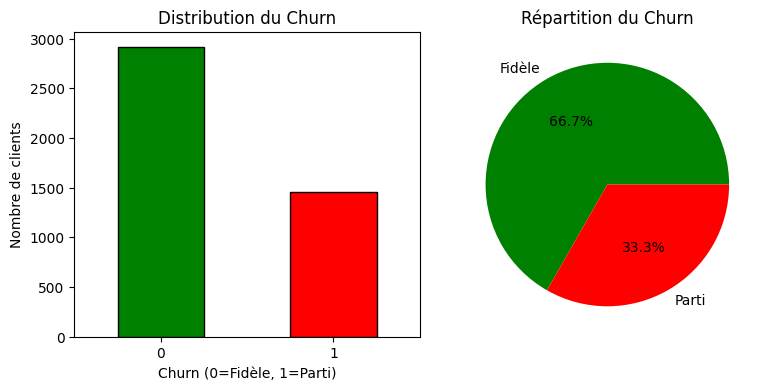

Churn
0    2918
1    1454
Name: count, dtype: int64

En pourcentage :
Churn
0    66.74
1    33.26
Name: proportion, dtype: float64


In [17]:
plt.figure(figsize=(8, 4))

# Graphique
plt.subplot(1, 2, 1)
df_raw['Churn'].value_counts().plot(
    kind='bar', 
    color=['green', 'red'],
    edgecolor='black'
)
plt.title('Distribution du Churn')
plt.xlabel('Churn (0=Fidèle, 1=Parti)')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)

# Camembert
plt.subplot(1, 2, 2)
df_raw['Churn'].value_counts().plot(
    kind='pie',
    labels=['Fidèle', 'Parti'],
    colors=['green', 'red'],
    autopct='%1.1f%%'
)
plt.title('Répartition du Churn')

plt.tight_layout()
plt.show()

# Chiffres
print(df_raw['Churn'].value_counts())
print("\nEn pourcentage :")
print((df_raw['Churn'].value_counts(normalize=True) * 100).round(2))
# onconclut qu'on un a un déséquilibre modéré (environ 70% de fidèles et 30% de partis).'


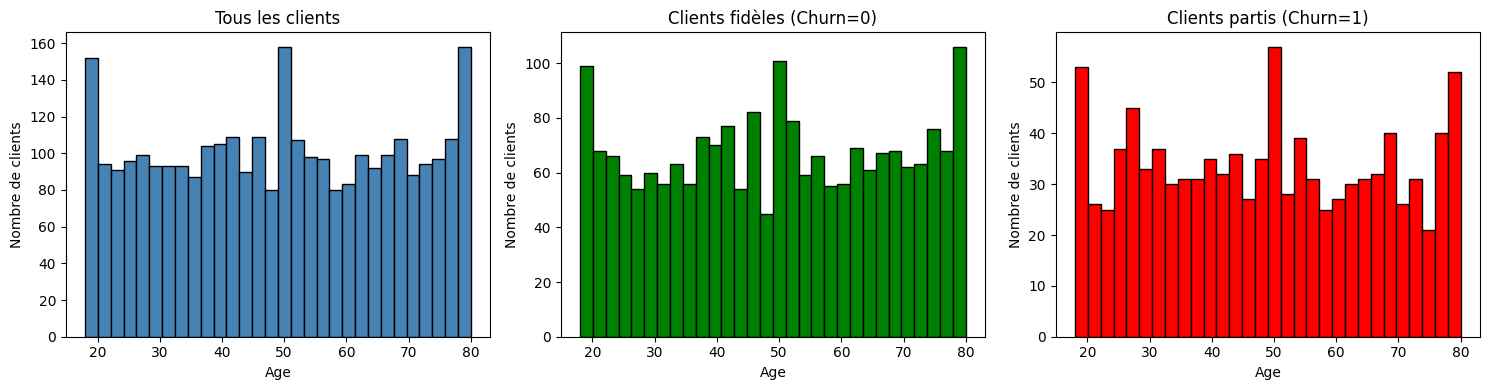

Moyenne d'âge :
Tous les clients : 49.1 ans
Clients fidèles  : 49.4 ans
Clients partis   : 48.6 ans


In [18]:
plt.figure(figsize=(15, 4))

# Graphique 1 — Tous les clients
plt.subplot(1, 3, 1)
plt.hist(df_raw['Age'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('Tous les clients')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')

# Graphique 2 — Clients fidèles seulement
plt.subplot(1, 3, 2)
plt.hist(df_raw[df_raw['Churn']==0]['Age'].dropna(), bins=30,
         color='green', edgecolor='black')
plt.title('Clients fidèles (Churn=0)')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')

# Graphique 3 — Clients partis seulement
plt.subplot(1, 3, 3)
plt.hist(df_raw[df_raw['Churn']==1]['Age'].dropna(), bins=30,
         color='red', edgecolor='black')
plt.title('Clients partis (Churn=1)')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')

plt.tight_layout()
plt.show()

# Statistiques
print("Moyenne d'âge :")
print(f"Tous les clients : {df_raw['Age'].mean():.1f} ans")
print(f"Clients fidèles  : {df_raw[df_raw['Churn']==0]['Age'].mean():.1f} ans")
print(f"Clients partis   : {df_raw[df_raw['Churn']==1]['Age'].mean():.1f} ans")
# L'âge n'est PAS une feature importante pour prédire le Churn

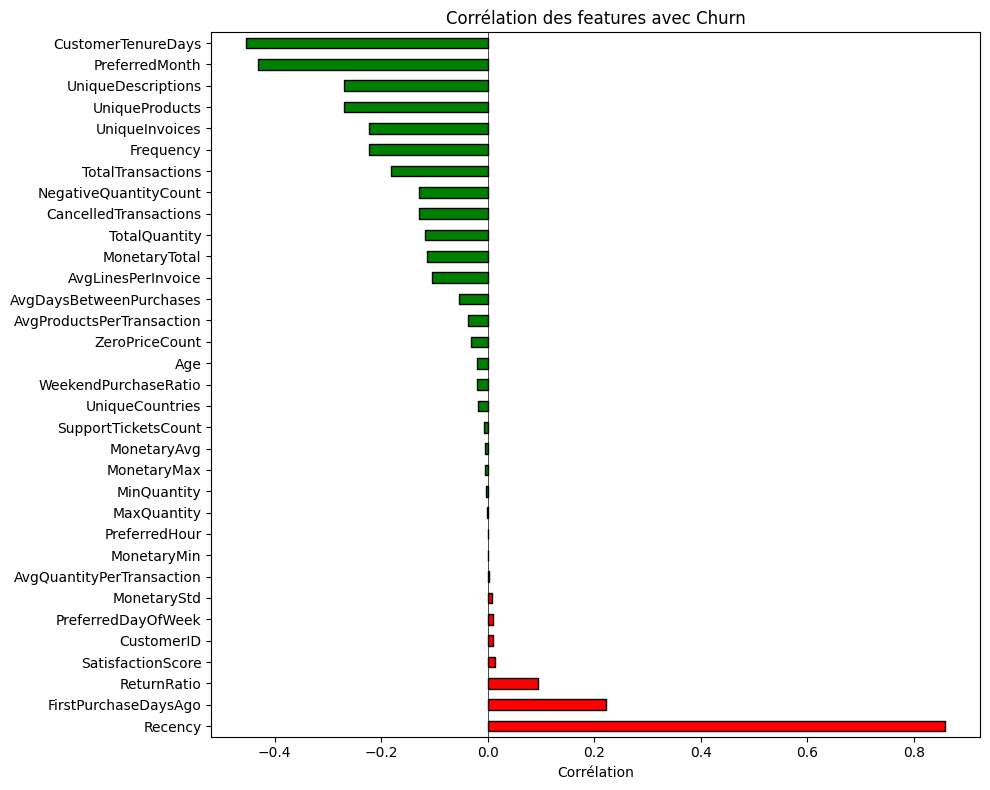

 Top 5 features qui AUGMENTENT le Churn :
Recency                 0.858951
FirstPurchaseDaysAgo    0.221612
ReturnRatio             0.093914
SatisfactionScore       0.013698
CustomerID              0.010514
Name: Churn, dtype: float64

 Top 5 features qui DIMINUENT le Churn :
UniqueInvoices       -0.222616
UniqueProducts       -0.269833
UniqueDescriptions   -0.269835
PreferredMonth       -0.430943
CustomerTenureDays   -0.453455
Name: Churn, dtype: float64


In [19]:
plt.figure(figsize=(10, 8))

# Corrélation de toutes les features numériques avec Churn
correlation = df_raw.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

# Supprimer Churn lui même
correlation = correlation.drop('Churn')

# Graphique
correlation.plot(kind='barh', 
                color=['red' if x > 0 else 'green' for x in correlation],
                edgecolor='black',
                figsize=(10, 8))

plt.title('Corrélation des features avec Churn')
plt.xlabel('Corrélation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Top 5 features les plus corrélées
print(" Top 5 features qui AUGMENTENT le Churn :")
print(correlation.head(5))
print("\n Top 5 features qui DIMINUENT le Churn :")
print(correlation.tail(5))
# Pour trouver  quelles features sont vraiment liées au Churn — sans regarder chaque feature une par une.


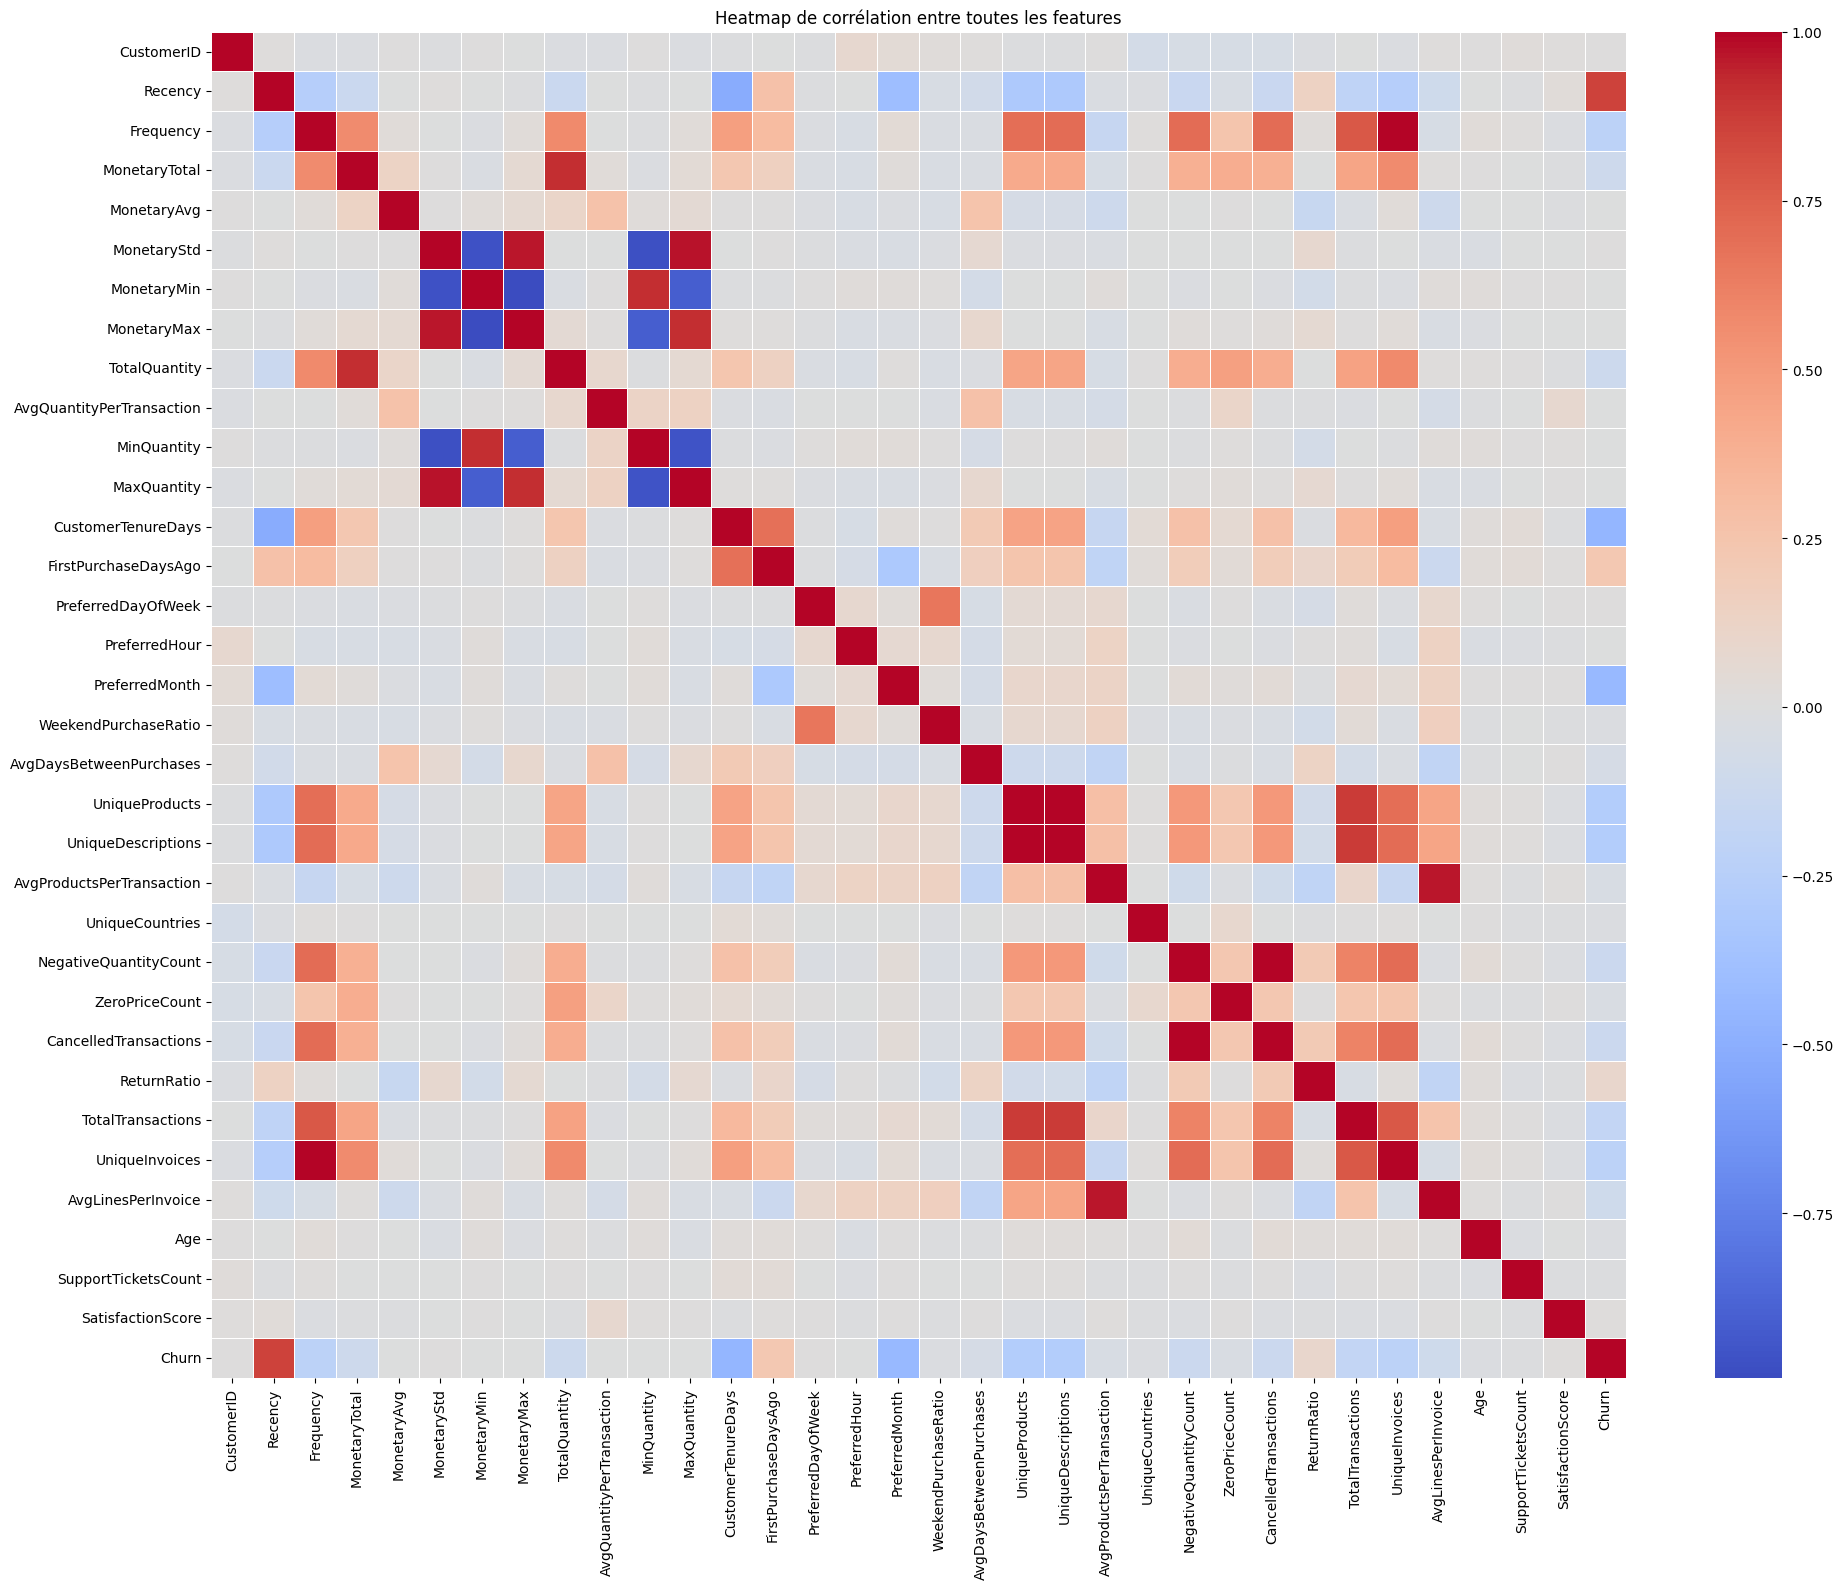

  Features très corrélées (|corrélation| > 0.8) :
Recency ↔ Churn : 0.86
Frequency ↔ UniqueInvoices : 1.00
MonetaryTotal ↔ TotalQuantity : 0.92
MonetaryStd ↔ MonetaryMin : -0.97
MonetaryStd ↔ MonetaryMax : 0.97
MonetaryStd ↔ MinQuantity : -0.97
MonetaryStd ↔ MaxQuantity : 0.97
MonetaryMin ↔ MonetaryStd : -0.97
MonetaryMin ↔ MonetaryMax : -0.99
MonetaryMin ↔ MinQuantity : 0.92
MonetaryMin ↔ MaxQuantity : -0.92
MonetaryMax ↔ MonetaryStd : 0.97
MonetaryMax ↔ MonetaryMin : -0.99
MonetaryMax ↔ MinQuantity : -0.92
MonetaryMax ↔ MaxQuantity : 0.92
TotalQuantity ↔ MonetaryTotal : 0.92
MinQuantity ↔ MonetaryStd : -0.97
MinQuantity ↔ MonetaryMin : 0.92
MinQuantity ↔ MonetaryMax : -0.92
MinQuantity ↔ MaxQuantity : -0.96
MaxQuantity ↔ MonetaryStd : 0.97
MaxQuantity ↔ MonetaryMin : -0.92
MaxQuantity ↔ MonetaryMax : 0.92
MaxQuantity ↔ MinQuantity : -0.96
UniqueProducts ↔ UniqueDescriptions : 1.00
UniqueProducts ↔ TotalTransactions : 0.88
UniqueDescriptions ↔ UniqueProducts : 1.00
UniqueDescriptions 

In [22]:
plt.figure(figsize=(20, 16))

# Calculer la matrice de corrélation
correlation_matrix = df_raw.corr(numeric_only=True)

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=False,        # pas de chiffres (trop de colonnes)
    cmap='coolwarm',    # rouge=corrélation positive, bleu=négative
    center=0,
    linewidths=0.5
)

plt.title('Heatmap de corrélation entre toutes les features')
plt.tight_layout()
plt.show()

# Features très corrélées entre elles (redondantes)
print("  Features très corrélées (|corrélation| > 0.8) :")
for col in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if col != row:
            if abs(correlation_matrix[col][row]) > 0.8:
                print(f"{col} ↔ {row} : {correlation_matrix[col][row]:.2f}")
# Pour détecter les features redondantes — deux features qui donnent la même information sont inutiles ensemble.


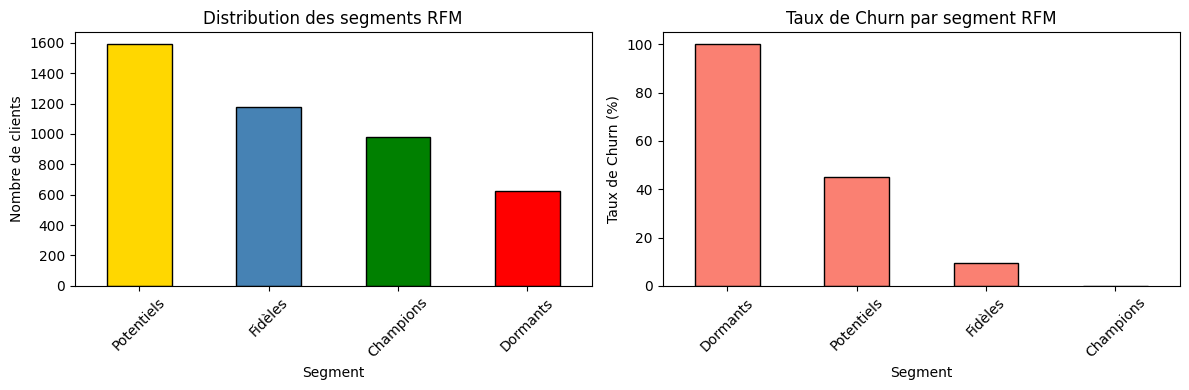

Taux de Churn par segment RFM :
RFMSegment
Champions       0.00
Dormants      100.00
Fidèles         9.35
Potentiels     45.12
Name: Churn, dtype: float64


In [21]:
plt.figure(figsize=(12, 4))

# Distribution des segments
plt.subplot(1, 2, 1)
df_raw['RFMSegment'].value_counts().plot(
    kind='bar',
    color=['gold', 'steelblue', 'green', 'red'],
    edgecolor='black'
)
plt.title('Distribution des segments RFM')
plt.xlabel('Segment')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)

# Churn par segment RFM
plt.subplot(1, 2, 2)
churn_par_segment = df_raw.groupby('RFMSegment')['Churn'].mean() * 100
churn_par_segment.sort_values(ascending=False).plot(
    kind='bar',
    color='salmon',
    edgecolor='black'
)
plt.title('Taux de Churn par segment RFM')
plt.xlabel('Segment')
plt.ylabel('Taux de Churn (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Chiffres
print("Taux de Churn par segment RFM :")
print((df_raw.groupby('RFMSegment')['Churn'].mean() * 100).round(2))

In [15]:
import pandas as pd
import sys
sys.path.append(r'C:\Users\abdal\Desktop\projects\ML\ML_project\src')
from utils import analyser_redondantes

df = pd.read_csv(r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\raw\retail_customers_COMPLETE CATEGORICAL.csv')

# Vérification faille 1
colonnes = analyser_redondantes(df, seuil=0.85)
print('Recency supprimée ?', 'Recency' in colonnes)
print('Churn supprimé ?', 'Churn' in colonnes)

# Vérification faille 2
print('\nCorrélation TotalQuantity vs MonetaryTotal vs Churn:')
print(df[['TotalQuantity', 'MonetaryTotal', 'Churn']].corr())


 COLONNES REDONDANTES (corrélation > 0.85)
 UniqueInvoices redondante avec Frequency (corrélation = 1.00)
 TotalQuantity redondante avec MonetaryTotal (corrélation = 0.92)
 MonetaryMin redondante avec MonetaryStd (corrélation = -0.97)
 MonetaryMax redondante avec MonetaryStd (corrélation = 0.97)
 MinQuantity redondante avec MonetaryStd (corrélation = -0.97)
 MaxQuantity redondante avec MonetaryStd (corrélation = 0.97)
 UniqueDescriptions redondante avec UniqueProducts (corrélation = 1.00)
 TotalTransactions redondante avec UniqueProducts (corrélation = 0.88)
 AvgLinesPerInvoice redondante avec AvgProductsPerTransaction (corrélation = 0.96)
 CancelledTransactions redondante avec NegativeQuantityCount (corrélation = 1.00)

→ 10 colonnes redondantes détectées
Recency supprimée ? False
Churn supprimé ? False

Corrélation TotalQuantity vs MonetaryTotal vs Churn:
               TotalQuantity  MonetaryTotal     Churn
TotalQuantity       1.000000       0.921649 -0.116986
MonetaryTotal       0